### iLIQ Analysis

Notebook for analyzing lickometer CSV files generated by this firmware.

Expected CSV format:
- Row 1: `SchemaVersion,1`
- Row 2: `Time(ms),WallTime,Electrode,Event`
- Data rows include system events (`E-`) and touch events (`E0..E11`, `START`/`STOP`).


In [251]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [252]:
schema = pd.read_csv('/Users/haggertydl/Desktop/iLIQ/Analysis/analysis_demo_log.csv', header=None, nrows = 1).iloc[0].to_list()
print(f"{schema[0]}: {schema[1]} ")

SchemaVersion: 1 


In [253]:
df = pd.read_csv('/Users/haggertydl/Desktop/iLIQ/Analysis/analysis_demo_log.csv', skiprows=1)

df['WallTime'] = pd.to_datetime(df['WallTime'], errors='coerce')
df['Time_Elapsed'] = pd.to_timedelta(df['Time(ms)'] - df['Time(ms)'].iloc[0], unit='ms')

anchor_start = df.loc[df['Event'] == 'SESSION_START', 'WallTime'].iloc[0]
df['AbsoluteTime'] = anchor_start + df['Time_Elapsed']

session_start = df.loc[df['Event'] == 'SESSION_START', 'AbsoluteTime'].iloc[0]
session_stop  = df.loc[df['Event'] == 'SESSION_STOP',  'AbsoluteTime'].iloc[0]

df['Time_Elapsed_s'] = df['Time_Elapsed'].dt.total_seconds()

df.drop(columns=['Time(ms)', 'WallTime'], inplace=True)

df.head()

,Electrode,Event,Time_Elapsed,AbsoluteTime,Time_Elapsed_s
0,E-,SESSION_START,0 days 00:00:00,2026-03-13 11:14:41.000,0.000
1,E0,START,0 days 00:00:00.981000,2026-03-13 11:14:41.981,0.981
2,E0,STOP,0 days 00:00:01.074000,2026-03-13 11:14:42.074,1.074
3,E0,START,0 days 00:00:01.213000,2026-03-13 11:14:42.213,1.213
4,E0,STOP,0 days 00:00:01.302000,2026-03-13 11:14:42.302,1.302


In [254]:
for i in df.loc[df['Electrode'] != 'E-']['Electrode'].unique():
    current_electrode = df.loc[(df['Electrode'] == i) | (df['Event'].isin(['SESSION_START', 'SESSION_STOP']))].copy()
    current_electrode['Licks'] = (current_electrode['Event'] == 'START').cumsum()
    for j in current_electrode.loc[current_electrode['Electrode'] != 'E-']['Licks'].unique():
        current_electrode.loc[(current_electrode['Licks'] == j), 'LickDuration'] = current_electrode.loc[(current_electrode['Licks'] == j) & (current_electrode['Event'] == 'STOP'), 'AbsoluteTime'].iloc[0] - current_electrode.loc[(current_electrode['Licks'] == j) & (current_electrode['Event'] == 'START'), 'AbsoluteTime'].iloc[0]

In [258]:
current_electrode

,Electrode,Event,Time_Elapsed,AbsoluteTime,Time_Elapsed_s,Licks,LickDuration
0,E-,SESSION_START,0 days 00:00:00,2026-03-13 11:14:41.000,0.000,0,NaT
1,E0,START,0 days 00:00:00.981000,2026-03-13 11:14:41.981,0.981,1,0 days 00:00:00.093000
2,E0,STOP,0 days 00:00:01.074000,2026-03-13 11:14:42.074,1.074,1,0 days 00:00:00.093000
3,E0,START,0 days 00:00:01.213000,2026-03-13 11:14:42.213,1.213,2,0 days 00:00:00.089000
4,E0,STOP,0 days 00:00:01.302000,2026-03-13 11:14:42.302,1.302,2,0 days 00:00:00.089000
...,...,...,...,...,...,...,...
141,E0,START,0 days 00:01:33.921000,2026-03-13 11:16:14.921,93.921,71,0 days 00:00:00.008000
142,E0,STOP,0 days 00:01:33.929000,2026-03-13 11:16:14.929,93.929,71,0 days 00:00:00.008000
143,E0,START,0 days 00:01:33.938000,2026-03-13 11:16:14.938,93.938,72,0 days 00:00:00.064000
144,E0,STOP,0 days 00:01:34.002000,2026-03-13 11:16:15.002,94.002,72,0 days 00:00:00.064000


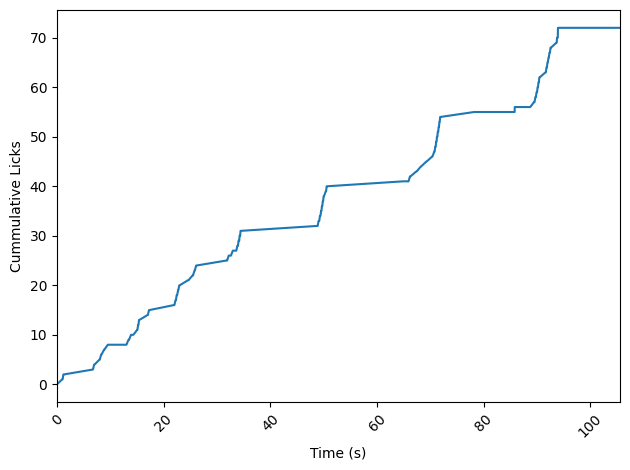

In [259]:
sns.lineplot(data=current_electrode, x='Time_Elapsed_s', y='Licks')

plt.xlim(current_electrode['Time_Elapsed_s'].min(), current_electrode['Time_Elapsed_s'].max())
plt.xticks(rotation=45)

plt.ylabel('Cummulative Licks')
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()